# Cue-centered semantic CRP

Recall probability as a function of semantic distance from the preceding film cue. This parallels the temporal cue-centered CRP but bins by cosine distance between clip embeddings instead of temporal lag.

The question: when a cue triggers a recall, does the recalled clip tend to be semantically similar to the cue, independent of temporal proximity? A declining CRP with increasing distance from the cue would indicate that cues bias recall toward semantically related clips.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.helpers import find_project_root, load_data
from jaxcmr.selective_interference.analysis import derive_cue_clips

warnings.filterwarnings("ignore")

In [2]:
run_tag = "VRT_CUE_CENTERED_DISTCRP"
data_path = "data/VRT_clips.h5"
embeddings_path = "data/VRT_clip_embeddings.npy"
figure_dir = "results/figures"
figure_str = ""
n_bins = 5

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
embeddings_path = os.path.join(project_root, embeddings_path)

data = load_data(data_path)
embeddings = np.load(embeddings_path)

recalls = np.array(data["recalls"])
pres_itemids = np.array(data["pres_itemids"])
cue_clips = derive_cue_clips(
    np.array(data["recall_items"]),
    np.array(data["recall_types"]),
    recalls,
)

task = np.array(data["task"]).reshape(-1)
condition = np.array(data["condition"]).reshape(-1)
intervention = np.array(data["intervention"]).reshape(-1)
subjects = np.array(data["subject"]).reshape(-1)

print(f"Loaded {recalls.shape[0]} trials")
print(f"Embeddings shape: {embeddings.shape}")

Loaded 240 trials
Embeddings shape: (22, 768)


## Building the distance matrix and bin edges

The embeddings matrix is 22x768 (rows 0-10 = emotional clips, 11-21 = neutral clips), indexed as `embeddings[pres_itemids - 1]`. We compute cosine distance (1 - cosine similarity) between all pairs, then derive bin edges from the percentiles of the upper triangle of the within-film distance matrix.

Since each trial only uses 11 of the 22 clips (all emotional or all neutral), the relevant distances for any given trial are within a single film. We compute bin edges from the pooled upper-triangle distances across both films to get a common binning.

In [4]:
# Cosine distance matrix over all 22 clips
norms = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
similarity = norms @ norms.T
distance_matrix = 1.0 - similarity

# Collect within-film pairwise distances for bin edge computation
within_film_distances = []
for film_ids in [np.arange(0, 11), np.arange(11, 22)]:
    sub = distance_matrix[np.ix_(film_ids, film_ids)]
    upper = sub[np.triu_indices(11, k=1)]
    within_film_distances.append(upper)
all_within = np.concatenate(within_film_distances)

# Percentile-based bin edges
percentiles = np.linspace(0, 100, n_bins + 1)[1:-1]
bin_edges = np.percentile(all_within, percentiles)
full_edges = np.concatenate(([all_within.min()], bin_edges, [all_within.max()]))
bin_centers = 0.5 * (full_edges[:-1] + full_edges[1:])

print(f"Within-film distances: min={all_within.min():.3f}, max={all_within.max():.3f}")
print(f"Bin edges: {np.round(bin_edges, 3)}")
print(f"Bin centers: {np.round(bin_centers, 3)}")

Within-film distances: min=0.189, max=0.735
Bin edges: [0.428 0.495 0.536 0.585]
Bin centers: [0.309 0.461 0.515 0.56  0.66 ]


## Tabulation logic

For each trial, we walk the recall sequence. At each cued recall event (where `cue_clips > 0`), we:

1. Look up the cue's global item ID via `pres_itemids[cue_pos - 1]`
2. Compute the cosine distance from the cue to the recalled item and digitize it into a bin (actual count)
3. Compute cosine distances from the cue to all currently available items and increment their bins (available counts)
4. Mark the recalled item as unavailable

When the recall is uncued (`cue_clips == 0`), we still update availability but don't contribute to the CRP counts.

In [5]:
def cue_centered_distcrp_trial(recalls, cue_clips, pres_itemids, distance_matrix, bin_edges):
    """Compute actual and available distance-bin counts for one trial."""
    n_bins_total = len(bin_edges) + 1
    actual = np.zeros(n_bins_total, dtype=int)
    available = np.zeros(n_bins_total, dtype=int)
    list_length = (pres_itemids > 0).sum()
    avail = np.ones(list_length, dtype=bool)

    for r in range(len(recalls)):
        recall_pos = int(recalls[r])
        if recall_pos == 0:
            break
        cue_pos = int(cue_clips[r])

        if cue_pos > 0 and avail[recall_pos - 1]:
            cue_id = int(pres_itemids[cue_pos - 1]) - 1
            recall_id = int(pres_itemids[recall_pos - 1]) - 1

            # Actual transition
            d_actual = distance_matrix[cue_id, recall_id]
            actual[np.digitize(d_actual, bin_edges)] += 1

            # Available transitions
            for j in range(list_length):
                if avail[j]:
                    item_id = int(pres_itemids[j]) - 1
                    d_avail = distance_matrix[cue_id, item_id]
                    available[np.digitize(d_avail, bin_edges)] += 1

        if recall_pos <= list_length:
            avail[recall_pos - 1] = False

    return actual, available


def cue_centered_distcrp(mask, recalls, cue_clips, pres_itemids, distance_matrix, bin_edges, subjects):
    """Compute per-subject cue-centered semantic CRP.

    Returns an array of shape [n_subjects, n_bins] with CRP per distance bin.
    """
    n_bins_total = len(bin_edges) + 1
    unique_subs = np.unique(subjects[mask])
    subject_crps = []

    for s in unique_subs:
        sub_mask = mask & (subjects == s)
        trial_indices = np.where(sub_mask)[0]
        total_actual = np.zeros(n_bins_total, dtype=int)
        total_available = np.zeros(n_bins_total, dtype=int)

        for t in trial_indices:
            a, v = cue_centered_distcrp_trial(
                recalls[t], cue_clips[t], pres_itemids[t],
                distance_matrix, bin_edges,
            )
            total_actual += a
            total_available += v

        with np.errstate(invalid="ignore", divide="ignore"):
            crp = np.where(total_available > 0, total_actual / total_available, np.nan)
        subject_crps.append(crp)

    return np.array(subject_crps)

## Plotting helpers

In [6]:
def plot_cue_centered_distcrp(masks, labels, contrast_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (mask, label) in enumerate(zip(masks, labels)):
        subj_crps = cue_centered_distcrp(
            mask, recalls, cue_clips, pres_itemids,
            distance_matrix, bin_edges, subjects,
        )
        mean = np.nanmean(subj_crps, axis=0)
        se = np.nanstd(subj_crps, axis=0, ddof=1) / np.sqrt(
            np.sum(~np.isnan(subj_crps), axis=0)
        )
        ci = 1.96 * se
        color = colors[i % len(colors)]
        ax.plot(bin_centers, mean, "o-", color=color, label=label, markersize=5)
        ax.fill_between(bin_centers, mean - ci, mean + ci, alpha=0.2, color=color)
        n = int(mask.sum())
        print(f"{label}: n={n}, mean CRP range [{np.nanmin(mean):.3f}, {np.nanmax(mean):.3f}]")

    ax.set_xlabel("Semantic Distance from Cue (bin center)")
    ax.set_ylabel("Conditional Resp. Prob.")
    if contrast_name:
        ax.legend(title=contrast_name)
    else:
        ax.legend()
    return ax


def save_figure(fig_dir, fig_str, suffix=None):
    if not fig_str:
        plt.show()
        return
    os.makedirs(fig_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    path = os.path.join(fig_dir, f"{fig_str}{suffix_str}.png")
    plt.savefig(path, bbox_inches="tight", dpi=600)
    plt.show()

## All trials

First, the overall cue-centered semantic CRP across all 240 trials. If cues bias recall toward semantically similar clips, we should see higher CRP at lower distances.

All: n=240, mean CRP range [0.027, 0.436]


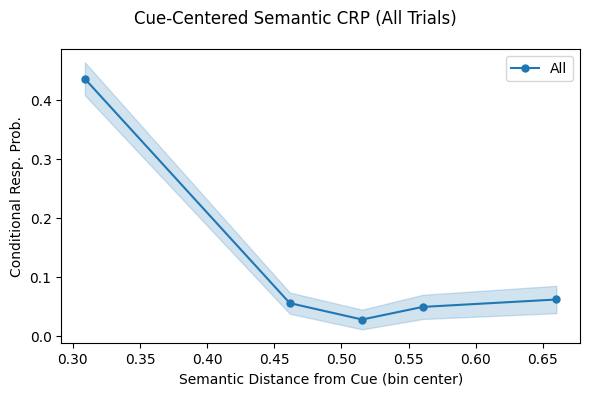

In [7]:
all_mask = np.ones(len(subjects), dtype=bool)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_cue_centered_distcrp([all_mask], ["All"], contrast_name=None, ax=ax)
fig.suptitle("Cue-Centered Semantic CRP (All Trials)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all")

## Task (involuntary vs voluntary)

Involuntary: n=120, mean CRP range [0.012, 0.447]
Voluntary: n=120, mean CRP range [0.044, 0.425]


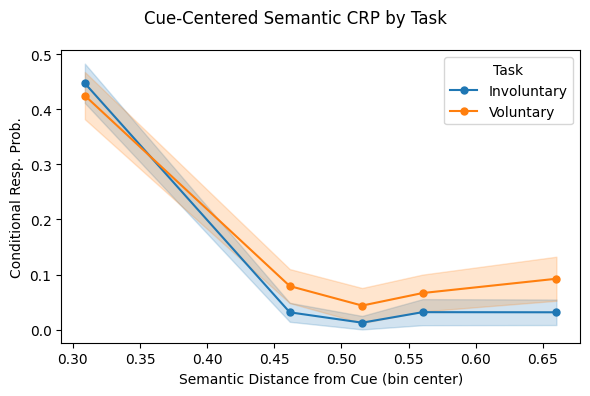

In [8]:
masks = [task == 1, task == 2]
labels = ["Involuntary", "Voluntary"]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_cue_centered_distcrp(masks, labels, "Task", ax=ax)
fig.suptitle("Cue-Centered Semantic CRP by Task")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task")

## Condition (emotional vs neutral)

Emotional and neutral films use different sets of clips with different inter-clip similarity structures. Differences here may reflect the semantic structure of the films rather than a cognitive effect.

Emotional: n=120, mean CRP range [0.033, 0.316]


Neutral: n=120, mean CRP range [0.022, 0.557]


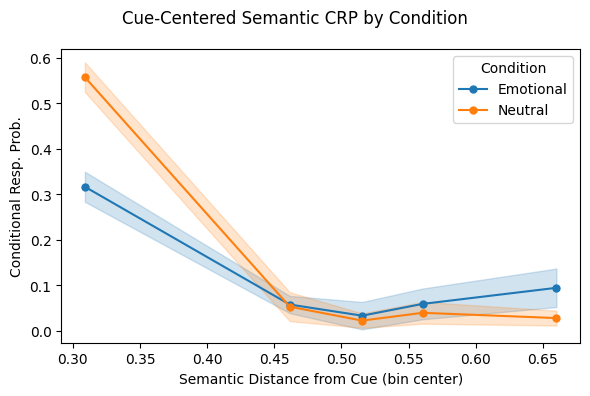

In [9]:
masks = [condition == 1, condition == 2]
labels = ["Emotional", "Neutral"]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_cue_centered_distcrp(masks, labels, "Condition", ax=ax)
fig.suptitle("Cue-Centered Semantic CRP by Condition")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition")

## Intervention (podcast vs Tetris)

Podcast: n=120, mean CRP range [0.029, 0.445]
Tetris: n=120, mean CRP range [0.023, 0.427]


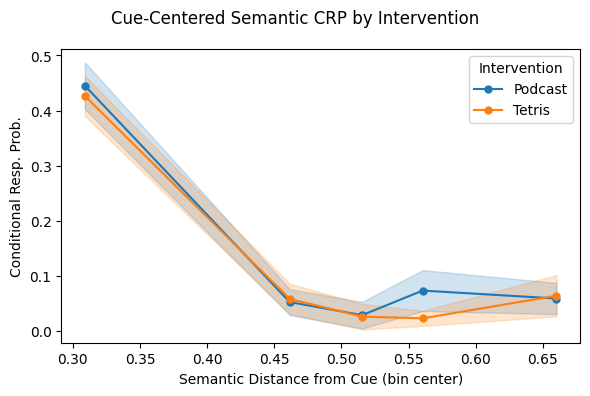

In [10]:
masks = [intervention == 0, intervention == 1]
labels = ["Podcast", "Tetris"]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_cue_centered_distcrp(masks, labels, "Intervention", ax=ax)
fig.suptitle("Cue-Centered Semantic CRP by Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention")

## Task x Condition

Emotional: n=60, mean CRP range [0.016, 0.304]
Neutral: n=60, mean CRP range [0.004, 0.591]
Emotional: n=60, mean CRP range [0.051, 0.328]
Neutral: n=60, mean CRP range [0.036, 0.523]


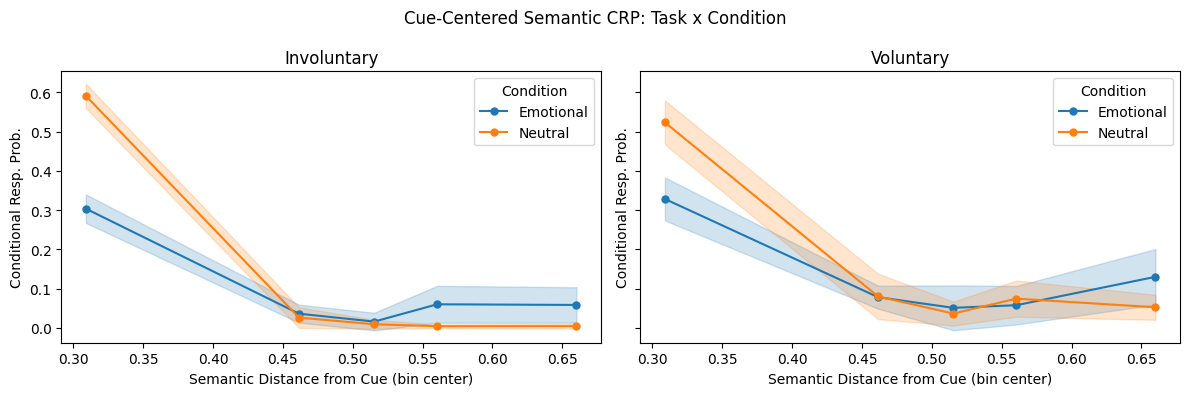

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Involuntary by condition
masks = [(task == 1) & (condition == 1), (task == 1) & (condition == 2)]
labels = ["Emotional", "Neutral"]
plot_cue_centered_distcrp(masks, labels, "Condition", ax=axes[0])
axes[0].set_title("Involuntary")

# Voluntary by condition
masks = [(task == 2) & (condition == 1), (task == 2) & (condition == 2)]
plot_cue_centered_distcrp(masks, labels, "Condition", ax=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Cue-Centered Semantic CRP: Task x Condition")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_condition")

## Task x Intervention

Podcast: n=60, mean CRP range [0.020, 0.451]
Tetris: n=60, mean CRP range [0.005, 0.443]
Podcast: n=60, mean CRP range [0.038, 0.439]
Tetris: n=60, mean CRP range [0.029, 0.411]


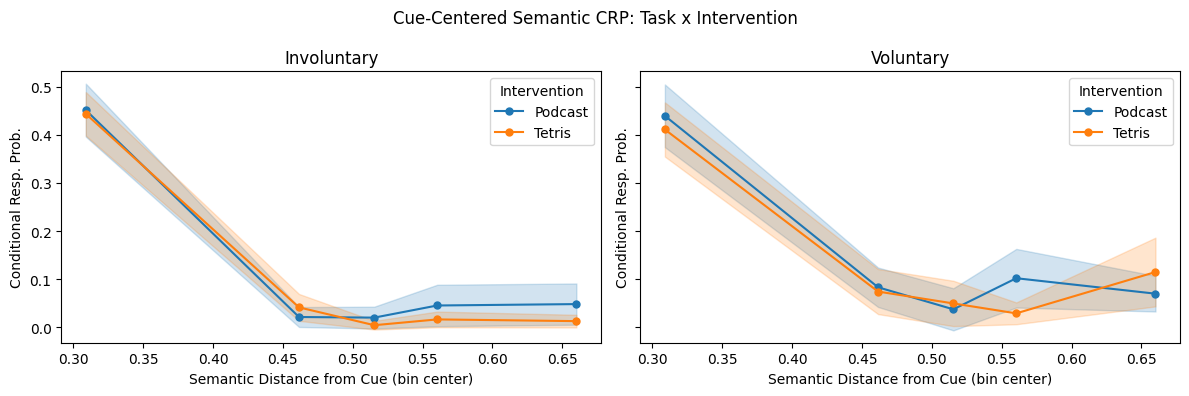

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Involuntary by intervention
masks = [(task == 1) & (intervention == 0), (task == 1) & (intervention == 1)]
labels = ["Podcast", "Tetris"]
plot_cue_centered_distcrp(masks, labels, "Intervention", ax=axes[0])
axes[0].set_title("Involuntary")

# Voluntary by intervention
masks = [(task == 2) & (intervention == 0), (task == 2) & (intervention == 1)]
plot_cue_centered_distcrp(masks, labels, "Intervention", ax=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Cue-Centered Semantic CRP: Task x Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intervention")

## Condition x Intervention

Podcast: n=60, mean CRP range [0.042, 0.324]
Tetris: n=60, mean CRP range [0.020, 0.309]
Podcast: n=60, mean CRP range [0.017, 0.565]
Tetris: n=60, mean CRP range [0.026, 0.549]


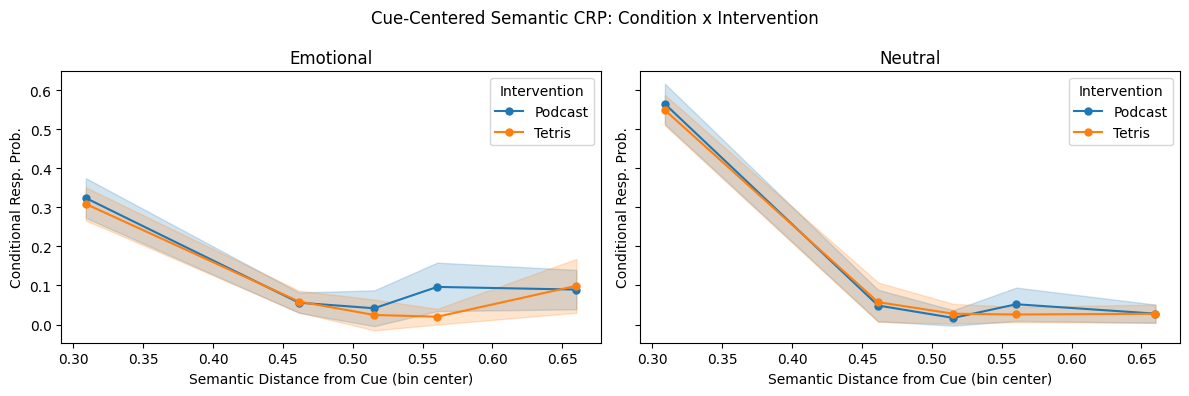

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Emotional by intervention
masks = [(condition == 1) & (intervention == 0), (condition == 1) & (intervention == 1)]
labels = ["Podcast", "Tetris"]
plot_cue_centered_distcrp(masks, labels, "Intervention", ax=axes[0])
axes[0].set_title("Emotional")

# Neutral by intervention
masks = [(condition == 2) & (intervention == 0), (condition == 2) & (intervention == 1)]
plot_cue_centered_distcrp(masks, labels, "Intervention", ax=axes[1])
axes[1].set_title("Neutral")

fig.suptitle("Cue-Centered Semantic CRP: Condition x Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition_intervention")